<a href="https://colab.research.google.com/github/MridulSharma02/AI-Powered-Stock-Price-Prediction-and-Trading-Strategy-Optimization/blob/main/AI_Powered_Stock_Price_Prediction_and_Trading_Strategy_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance ta seaborn plotly shap scikit-learn xgboost joblib

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=e53f5a32e1ec52846a99c051198324aa189670db9163726701002738e7eadb3c
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import plotly.graph_objects as go
import joblib

sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
TICKER = "AAPL"
START_DATE = "2015-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

df = yf.download(TICKER, start=START_DATE, end=END_DATE)
df.sort_index(inplace=True)
print(f"Downloaded {len(df)} rows for {TICKER}")

/tmp/ipython-input-3-1054959683.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Downloaded 2632 rows for AAPL


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.288584  24.757338  23.848709  24.746230  212818400
2015-01-05  23.604336  24.137516  23.417723  24.057539  257142000
2015-01-06  23.606552  23.866477  23.244433  23.668756  263188400
2015-01-07  23.937563  24.037534  23.704296  23.815375  160423600
2015-01-08  24.857300  24.915061  24.148614  24.266359  237458000
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-06-13  196.449997  200.369995  195.699997  199.729996  51447300
2025-06-16  198.419998  198.690002  196.559998  197.300003  43020700
2025-06-17  195.639999  198.389999  195.210007  197.199997  38856200
2025-06-18  196.580002  197.570007  195.070007  195.940002

<Figure size 1200x600 with 0 Axes>

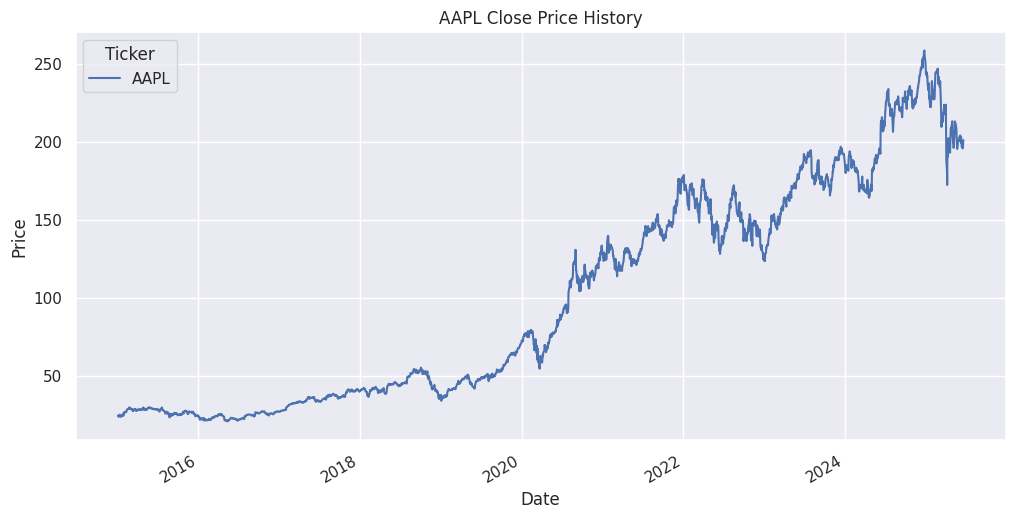

<Figure size 1200x600 with 0 Axes>

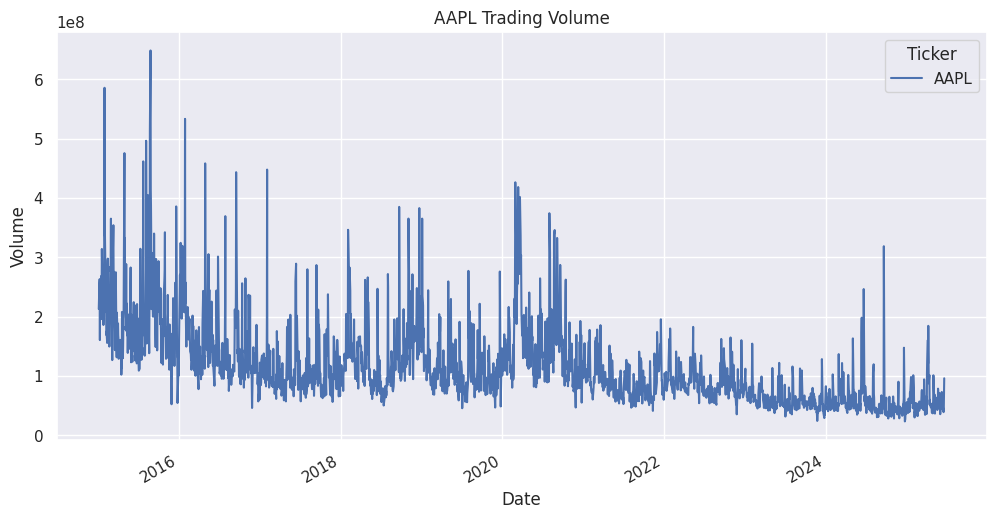

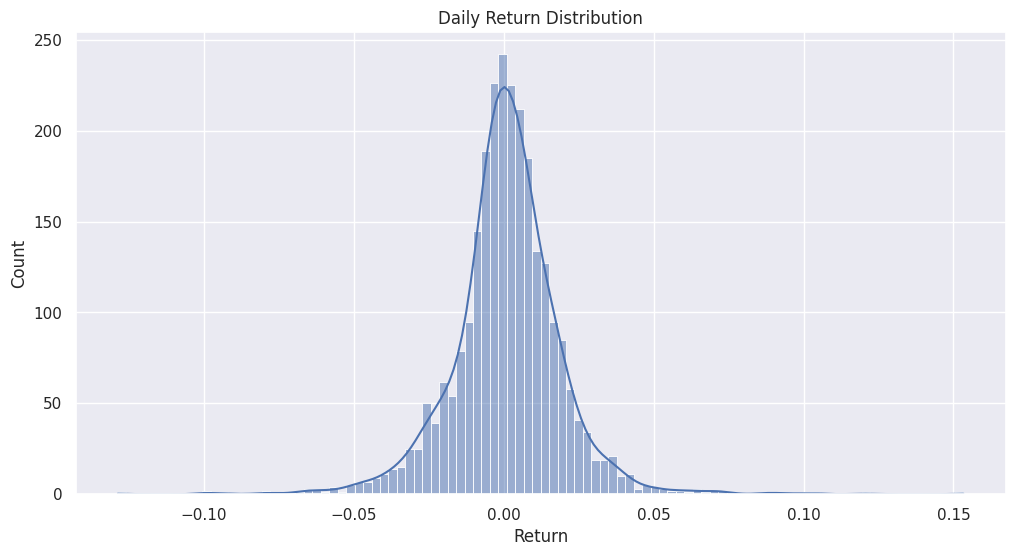

count    2631.000000
mean        0.000972
std         0.018385
min        -0.128647
25%        -0.007501
50%         0.000989
75%         0.010142
max         0.153288
Name: Return, dtype: float64


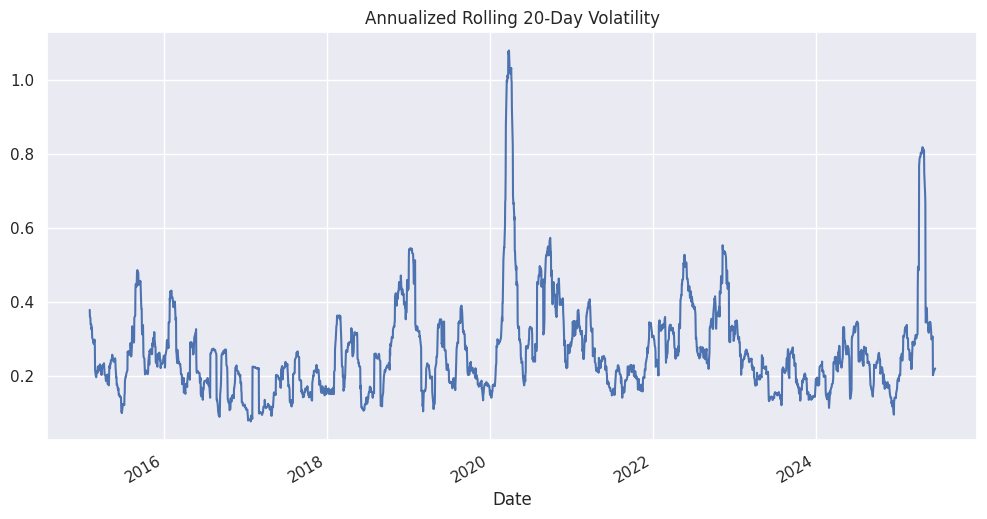

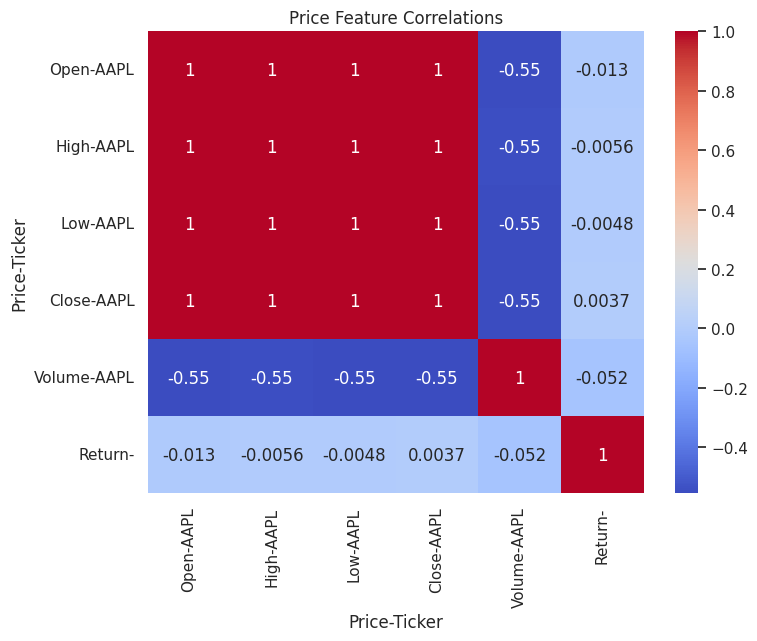

In [ ]:
print(df.head())
print(df.tail())
print(df.isnull().sum())

plt.figure()
df['Close'].plot(title=f'{TICKER} Close Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

plt.figure()
df['Volume'].plot(title=f'{TICKER} Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)

plt.figure()
sns.histplot(df['Return'], bins=100, kde=True)
plt.title('Daily Return Distribution')
plt.show()

print(df['Return'].describe())

df['volatility_20d'] = df['Return'].rolling(window=20).std() * np.sqrt(252)
plt.figure()
df['volatility_20d'].plot(title='Annualized Rolling 20-Day Volatility')
plt.show()

price_corr = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Return']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(price_corr, annot=True, cmap='coolwarm')
plt.title('Price Feature Correlations')
plt.show()

In [ ]:
df['rsi_14'] = ta.momentum.rsi(df['Close']['AAPL'], window=14)
macd = ta.trend.MACD(df['Close']['AAPL'])
df['macd'] = macd.macd()
df['macd_signal'] = macd.macd_signal()
df['macd_diff'] = macd.macd_diff()
bb = ta.volatility.BollingerBands(df['Close']['AAPL'], window=20, window_dev=2)
df['bb_high'] = bb.bollinger_hband()
df['bb_low'] = bb.bollinger_lband()
df['bb_percent'] = bb.bollinger_pband()
df['bb_width'] = bb.bollinger_wband()
df['ema_10'] = ta.trend.ema_indicator(df['Close']['AAPL'], window=10)
df['ema_20'] = ta.trend.ema_indicator(df['Close']['AAPL'], window=20)
df['ema_50'] = ta.trend.ema_indicator(df['Close']['AAPL'], window=50)
df['ema_100'] = ta.trend.ema_indicator(df['Close']['AAPL'], window=100)
df['sma_10'] = ta.trend.sma_indicator(df['Close']['AAPL'], window=10)
df['sma_20'] = ta.trend.sma_indicator(df['Close']['AAPL'], window=20)
df['sma_50'] = ta.trend.sma_indicator(df['Close']['AAPL'], window=50)
df['sma_100'] = ta.trend.sma_indicator(df['Close']['AAPL'], window=100)
df['mom_10'] = ta.momentum.roc(df['Close']['AAPL'], window=10)
df['mom_20'] = ta.momentum.roc(df['Close']['AAPL'], window=20)
df['volume_rolling_mean_20'] = df['Volume']['AAPL'].rolling(window=20).mean()
df['volume_rolling_std_20'] = df['Volume']['AAPL'].rolling(window=20).std()

for lag in [1, 2, 3, 5, 10]:
    df[f'return_lag_{lag}'] = df['Return'].shift(lag)

for window in [5, 10, 20]:
    df[f'return_roll_mean_{window}'] = df['Return'].rolling(window).mean()
    df[f'return_roll_std_{window}'] = df['Return'].rolling(window).std()

df.dropna(inplace=True)

In [ ]:
feature_cols = [
    'rsi_14', 'macd', 'macd_signal', 'macd_diff',
    'bb_percent', 'bb_width',
    'ema_10', 'ema_20', 'ema_50', 'ema_100',
    'sma_10', 'sma_20', 'sma_50', 'sma_100',
    'mom_10', 'mom_20',
    'volume_rolling_mean_20', 'volume_rolling_std_20'
]

lag_features = [f'return_lag_{lag}' for lag in [1, 2, 3, 5, 10]]
roll_features = [f'return_roll_mean_{window}' for window in [5, 10, 20]] + \
                [f'return_roll_std_{window}' for window in [5, 10, 20]]

feature_cols.extend(lag_features)
feature_cols.extend(roll_features)

df['target'] = df['Return'].shift(-1)
df.dropna(inplace=True)

X = df[feature_cols]
y = df['target']

NameError: name 'df' is not defined

In [ ]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f'Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}')

Train size: 1702, Val size: 364, Test size: 366


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_val_df = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

In [ ]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_df, y_train)

    val_preds = model.predict(X_val_df)
    test_preds = model.predict(X_test_df)

    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    val_r2 = r2_score(y_val, val_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"{name} Validation RMSE: {val_rmse:.6f}, R²: {val_r2:.4f}")
    print(f"{name} Test RMSE: {test_rmse:.6f}, R²: {test_r2:.4f}\n")

    results[name] = {
        "model": model,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse,
        "val_r2": val_r2,
        "test_r2": test_r2
    }

Training Random Forest...
Random Forest Validation RMSE: 0.017484, R²: -0.0864
Random Forest Test RMSE: 0.022457, R²: -0.4143

Training Linear Regression...
Linear Regression Validation RMSE: 0.016934, R²: -0.0191
Linear Regression Test RMSE: 0.018778, R²: 0.0111

Training XGBoost...
XGBoost Validation RMSE: 0.020204, R²: -0.4507
XGBoost Test RMSE: 0.023246, R²: -0.5155



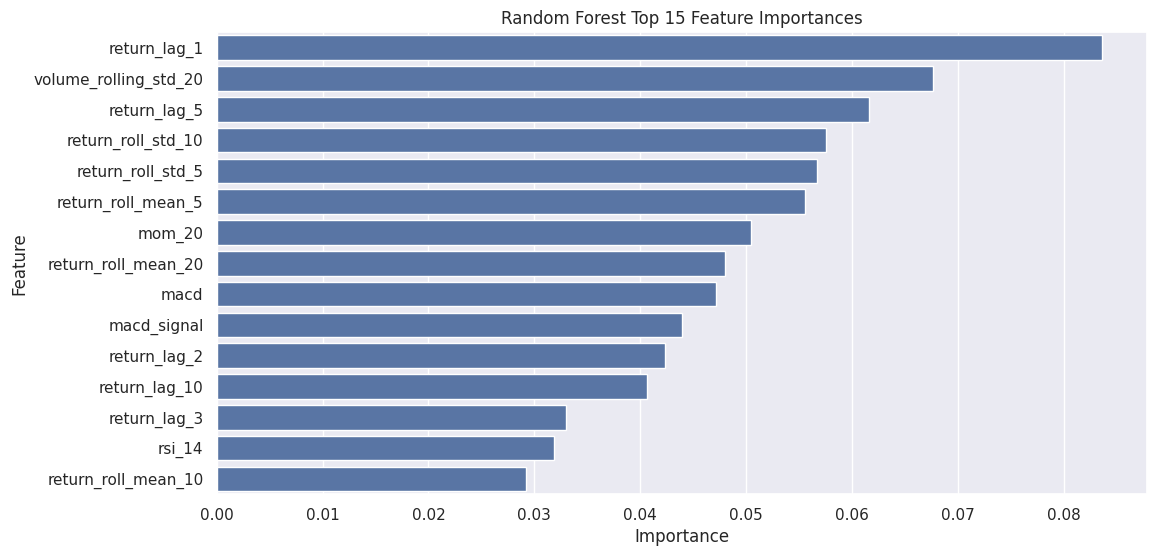

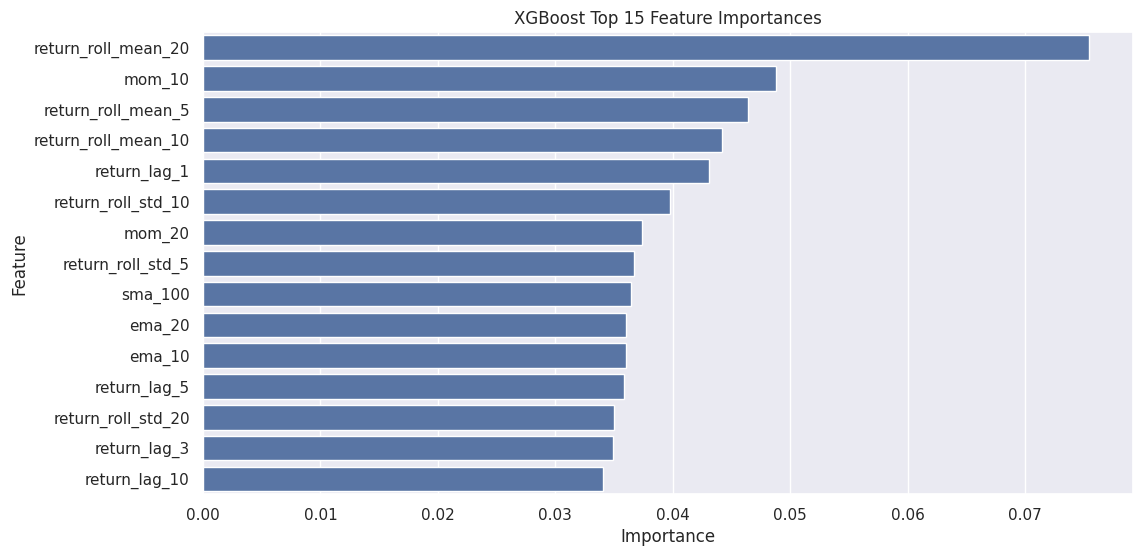

In [ ]:
for name in ['Random Forest', 'XGBoost']:
    model = results[name]['model']
    importances = model.feature_importances_
    imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    imp_df.sort_values(by='Importance', ascending=False, inplace=True)

    plt.figure(figsize=(12,6))
    sns.barplot(x='Importance', y='Feature', data=imp_df.head(15))
    plt.title(f'{name} Top 15 Feature Importances')
    plt.show()

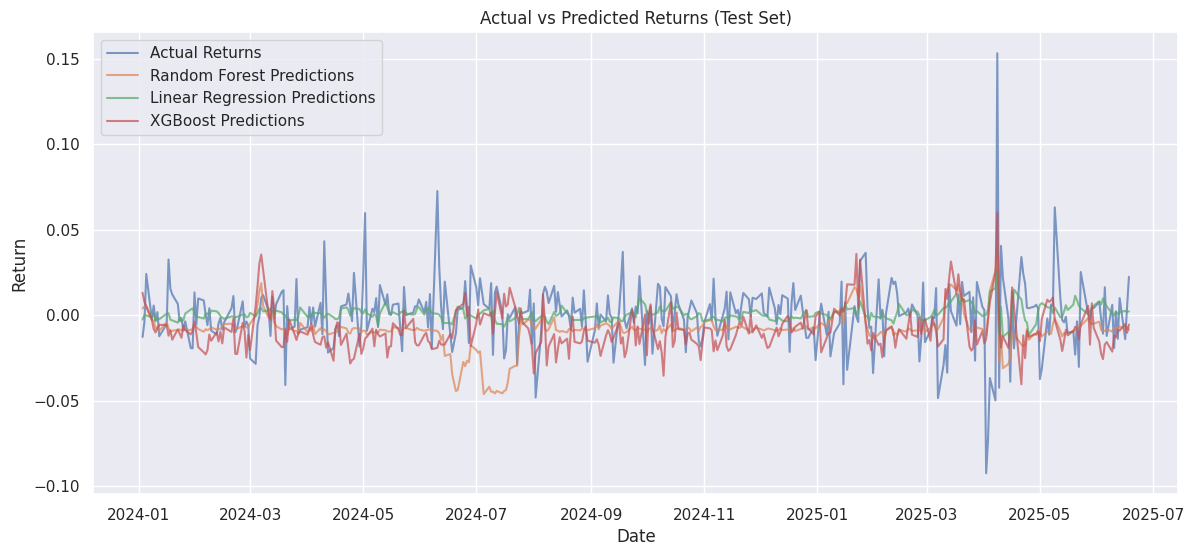

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Actual Returns', alpha=0.7)
for name in results:
    plt.plot(y_test.index, results[name]['test_preds'], label=f'{name} Predictions', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Returns (Test Set)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.show()

In [ ]:
best_model = results['Random Forest']['model']
best_test_preds = results['Random Forest']['test_preds']

signal_df = df.loc[X_test_df.index].copy()
signal_df['predicted_return'] = best_test_preds
signal_df['actual_return'] = y_test

threshold = 0.002

def trading_signal(row):
    if row['predicted_return'].item() > threshold and row['rsi_14'].item() < 30:
        return 1  # Buy
    elif row['predicted_return'].item() < -threshold or row['rsi_14'].item() > 70:
        return -1  # Sell
    else:
        return 0  # Hold

signal_df['signal'] = signal_df.apply(trading_signal, axis=1)
print(signal_df[['Close', 'predicted_return', 'rsi_14', 'signal']].tail())

Price            Close predicted_return     rsi_14 signal
Ticker            AAPL                                   
Date                                                     
2025-06-12  199.199997        -0.007888  44.351762     -1
2025-06-13  196.449997        -0.006502  40.802560     -1
2025-06-16  198.419998        -0.008379  44.244670     -1
2025-06-17  195.639999        -0.006771  40.652387     -1
2025-06-18  196.580002        -0.008550  42.356616     -1


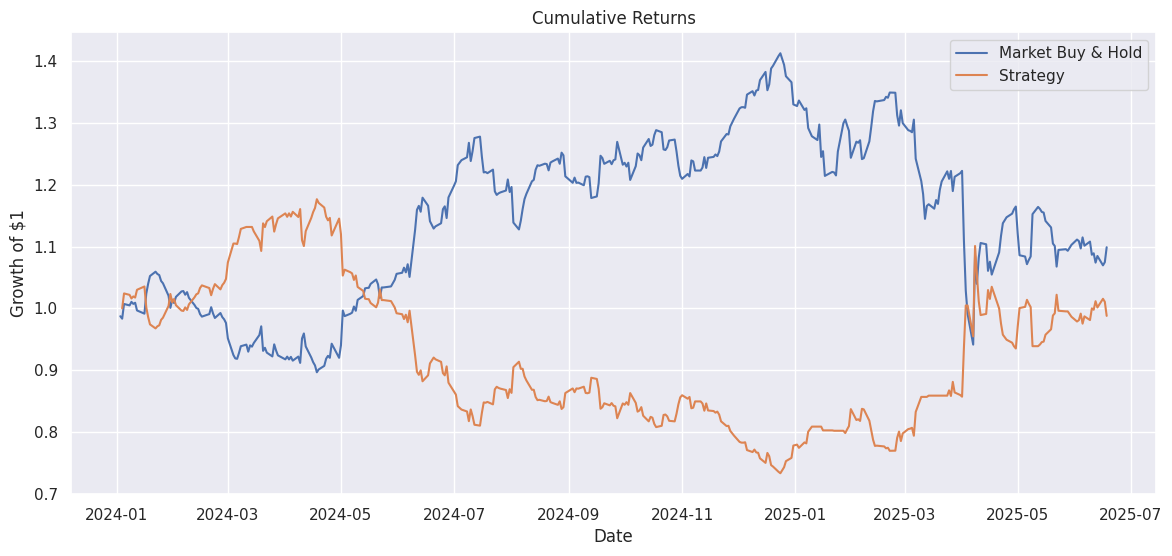

In [ ]:
signal_df['shifted_signal'] = signal_df['signal'].shift(1)
signal_df['strategy_return'] = signal_df['shifted_signal'] * signal_df['actual_return']

signal_df['cumulative_market_return'] = (1 + signal_df['actual_return']).cumprod()
signal_df['cumulative_strategy_return'] = (1 + signal_df['strategy_return']).cumprod()

plt.figure(figsize=(14,6))
plt.plot(signal_df.index, signal_df['cumulative_market_return'], label='Market Buy & Hold')
plt.plot(signal_df.index, signal_df['cumulative_strategy_return'], label='Strategy')
plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def annualized_return(returns, periods_per_year=252):
    return (1 + returns.mean())**periods_per_year - 1

def annualized_volatility(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)

def sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    excess_return = returns - risk_free_rate / periods_per_year
    return excess_return.mean() / returns.std() * np.sqrt(periods_per_year)

def max_drawdown(cum_returns):
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    return drawdown.min()

market_ann_return = annualized_return(signal_df['actual_return'])
market_ann_vol = annualized_volatility(signal_df['actual_return'])
market_sharpe = sharpe_ratio(signal_df['actual_return'])

strategy_ann_return = annualized_return(signal_df['strategy_return'])
strategy_ann_vol = annualized_volatility(signal_df['strategy_return'])
strategy_sharpe = sharpe_ratio(signal_df['strategy_return'])

strategy_max_dd = max_drawdown(signal_df['cumulative_strategy_return'])

print(f"Market Annualized Return: {market_ann_return:.2%}")
print(f"Market Annualized Volatility: {market_ann_vol:.2%}")
print(f"Market Sharpe Ratio: {market_sharpe:.2f}")

print(f"Strategy Annualized Return: {strategy_ann_return:.2%}")
print(f"Strategy Annualized Volatility: {strategy_ann_vol:.2%}")
print(f"Strategy Sharpe Ratio: {strategy_sharpe:.2f}")
print(f"Strategy Max Drawdown: {strategy_max_dd:.2%}")

Market Annualized Return: 11.56%
Market Annualized Volatility: 30.02%
Market Sharpe Ratio: 0.36
Strategy Annualized Return: 3.28%
Strategy Annualized Volatility: 28.85%
Strategy Sharpe Ratio: 0.11
Strategy Max Drawdown: -37.67%


In [ ]:
shap.initjs()
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values